# Modelos Predictivos — Ventas de Videojuegos
**Análisis de Negocios 2026-01 | Equipo ADN**

Este notebook entrena y compara tres modelos de regresión para predecir las ventas globales de videojuegos (`log_Global_Sales`):
1. Regresión Lineal (baseline)
2. Random Forest Regressor
3. XGBoost Regressor

Las métricas de evaluación utilizadas son RMSE, MAE y R².

## 1. Importación de librerías

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Carga y preprocesamiento del dataset

In [47]:
df = pd.read_csv('ventas_videojuegos_limpio.csv')
print(f'Shape original: {df.shape}')
df.head()

Shape original: (16715, 18)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,log_Global_Sales,Platform_encoded,Genre_encoded,Publisher_encoded
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,4.425206,26,10,361
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,3.719409,11,4,361
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,3.597860,26,6,361
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,3.519573,26,10,361
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,3.477232,5,7,361


In [48]:
# Verificar valores nulos en columnas relevantes
print('Valores nulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Valores nulos por columna:
Name               2
Genre              2
Publisher         54
Critic_Score    8578
Critic_Count    8578
User_Score      9125
User_Count      9125
dtype: int64


In [49]:
# ------------------------------------------------------------------
# Selección de features
# ------------------------------------------------------------------
# Se usan las variables codificadas (numéricas) más Year_of_Release.
# Critic_Score, User_Score y sus conteos se incluyen con imputación
# por mediana (ya realizada en la limpieza), pero dado que ~50% de
# registros tienen NaN originalmente, se crea una flag binaria para
# que el modelo capture esa señal.
# Las ventas regionales (NA, EU, JP, Other) se EXCLUYEN porque son
# componentes directas de Global_Sales → data leakage.
# ------------------------------------------------------------------

# Flag: ¿tenía critic score original? (proxy de popularidad/visibilidad)
df['has_critic_score'] = df['Critic_Score'].notna().astype(int)
df['has_user_score']   = df['User_Score'].notna().astype(int)

# Imputar mediana en columnas con nulos
for col in ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']:
    df[col] = df[col].fillna(df[col].median())

FEATURES = [
    'Year_of_Release',
    'Platform_encoded',
    'Genre_encoded',
    'Publisher_encoded',
    'Critic_Score',
    'Critic_Count',
    'User_Score',
    'User_Count',
    'has_critic_score',
    'has_user_score'
]

TARGET = 'log_Global_Sales'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'Features: {FEATURES}')
print(f'Target  : {TARGET}')
print(f'Shape X : {X.shape}')

Features: ['Year_of_Release', 'Platform_encoded', 'Genre_encoded', 'Publisher_encoded', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'has_critic_score', 'has_user_score']
Target  : log_Global_Sales
Shape X : (16715, 10)


In [50]:
# Train / Test split  (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} registros')
print(f'Test : {X_test.shape[0]} registros')

Train: 13372 registros
Test : 3343 registros


In [51]:
# Escalado para Regresión Lineal
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 3. Función de evaluación

In [52]:
def evaluar_modelo(nombre, y_real, y_pred):
    """Calcula RMSE, MAE y R² y devuelve un dict."""
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f'--- {nombre} ---')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  R²   : {r2:.4f}')
    return {'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

## 4. Modelo 1 — Regresión Lineal (Baseline)
Modelo de referencia. Asume relaciones lineales entre features y target.
Útil para establecer un piso de rendimiento.

In [53]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
metricas_lr = evaluar_modelo('Regresión Lineal', y_test, y_pred_lr)

--- Regresión Lineal ---
  RMSE : 0.3582
  MAE  : 0.2307
  R²   : 0.2226


In [54]:
# Validación cruzada (5-fold)
cv_lr = cross_val_score(
    LinearRegression(), X_train_sc, y_train,
    cv=5, scoring='r2'
)
print(f'CV R² (5-fold): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

CV R² (5-fold): 0.2493 ± 0.0176


## 5. Modelo 2 — Random Forest Regressor
Conjunto de árboles de decisión con muestreo aleatorio de registros y features.
Robusto a outliers y captura relaciones no lineales.

In [55]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
metricas_rf = evaluar_modelo('Random Forest', y_test, y_pred_rf)

--- Random Forest ---
  RMSE : 0.2930
  MAE  : 0.1766
  R²   : 0.4799


In [56]:
# Validación cruzada (5-fold)
cv_rf = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, cv=5, scoring='r2'
)
print(f'CV R² (5-fold): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

CV R² (5-fold): 0.4827 ± 0.0072


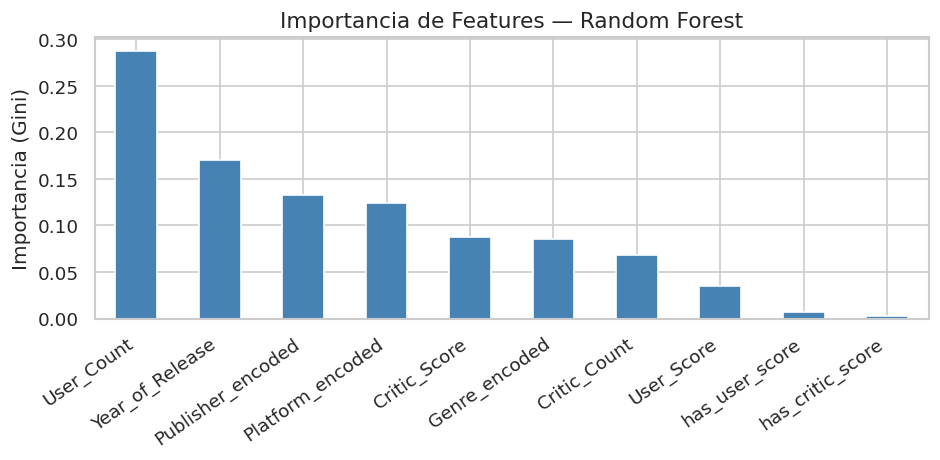

In [57]:
# Importancia de features — Random Forest
feat_imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
feat_imp_rf.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importancia de Features — Random Forest', fontsize=13)
ax.set_ylabel('Importancia (Gini)')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 6. Modelo 3 — XGBoost Regressor
Gradient Boosting con árboles. Construye árboles de forma secuencial,
corrigiendo los errores del árbol anterior. Generalmente obtiene métricas
comparables o superiores a Random Forest.

In [58]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred_xgb = xgb.predict(X_test)
metricas_xgb = evaluar_modelo('XGBoost', y_test, y_pred_xgb)

--- XGBoost ---
  RMSE : 0.2800
  MAE  : 0.1708
  R²   : 0.5250


In [59]:
# Validación cruzada (5-fold)
cv_xgb = cross_val_score(
    XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE,
                 verbosity=0, n_jobs=-1),
    X_train, y_train, cv=5, scoring='r2'
)
print(f'CV R² (5-fold): {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')

CV R² (5-fold): 0.5276 ± 0.0109


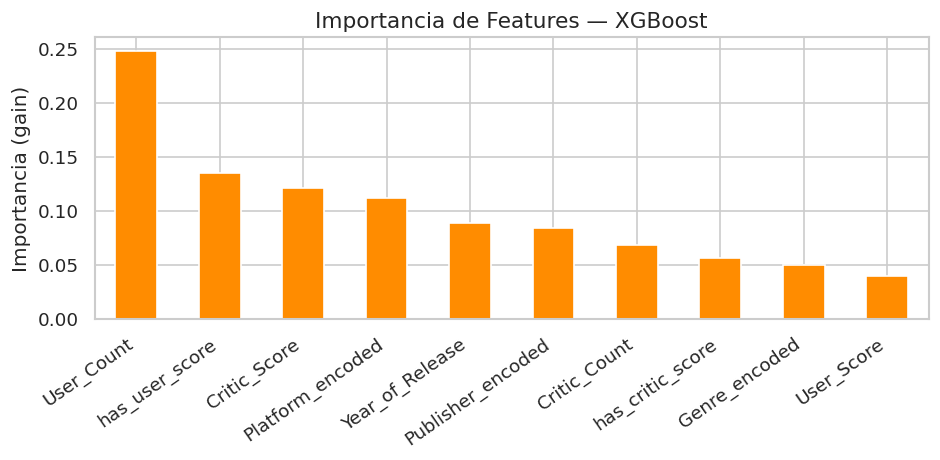

In [60]:
# Importancia de features — XGBoost
feat_imp_xgb = pd.Series(
    xgb.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
feat_imp_xgb.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Importancia de Features — XGBoost', fontsize=13)
ax.set_ylabel('Importancia (gain)')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 7. Comparación de modelos

In [61]:
resultados = pd.DataFrame([metricas_lr, metricas_rf, metricas_xgb])
resultados = resultados.set_index('Modelo')
resultados['RMSE'] = resultados['RMSE'].round(4)
resultados['MAE']  = resultados['MAE'].round(4)
resultados['R2']   = resultados['R2'].round(4)
print(resultados.to_string())
resultados

                    RMSE     MAE      R2
Modelo                                  
Regresión Lineal  0.3582  0.2307  0.2226
Random Forest     0.2930  0.1766  0.4799
XGBoost           0.2800  0.1708  0.5250


,RMSE,MAE,R2
Modelo,,,
Regresión Lineal,0.3582,0.2307,0.2226
Random Forest,0.2930,0.1766,0.4799
XGBoost,0.2800,0.1708,0.5250


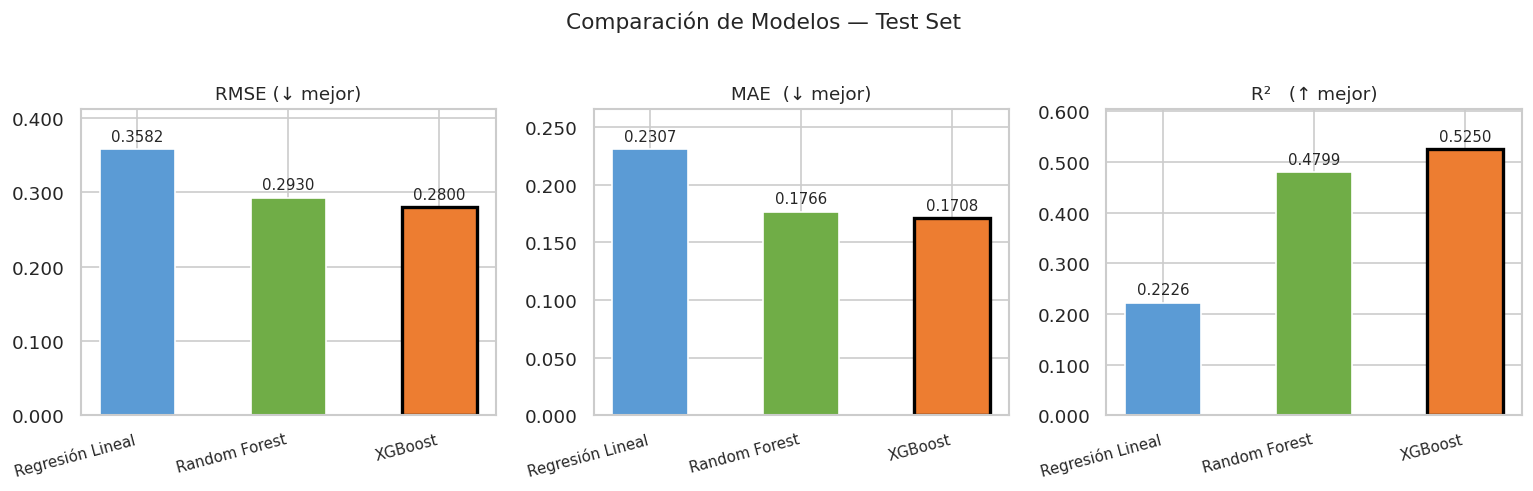

In [62]:
# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colores = ['#5B9BD5', '#70AD47', '#ED7D31']
modelos = resultados.index.tolist()

for ax, (metric, label, mejor) in zip(
    axes,
    [('RMSE', 'RMSE (↓ mejor)', 'min'),
     ('MAE',  'MAE  (↓ mejor)', 'min'),
     ('R2',   'R²   (↑ mejor)', 'max')]
):
    vals = resultados[metric].values
    bars = ax.bar(modelos, vals, color=colores, edgecolor='white', width=0.5)
    best_idx = np.argmin(vals) if mejor == 'min' else np.argmax(vals)
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.15)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.suptitle('Comparación de Modelos — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

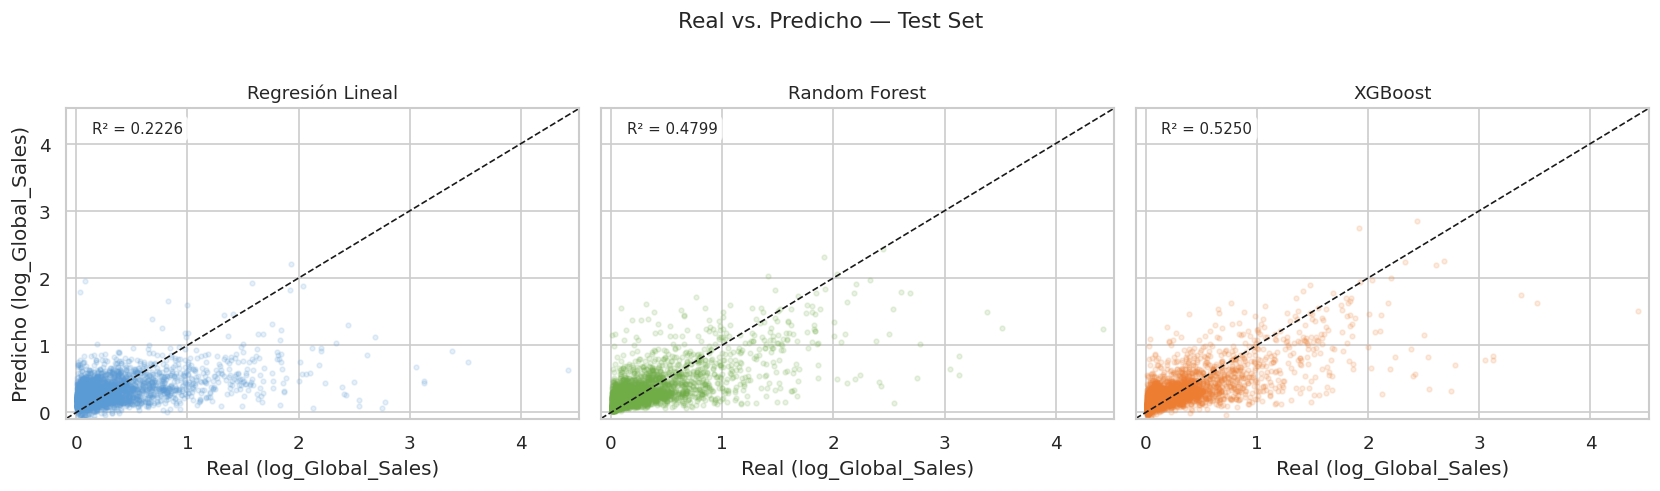

In [63]:
# Gráfico Real vs Predicho para los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

pares = [
    ('Regresión Lineal', y_pred_lr, '#5B9BD5'),
    ('Random Forest',   y_pred_rf, '#70AD47'),
    ('XGBoost',         y_pred_xgb,'#ED7D31'),
]

lims = (y_test.min() - 0.1, y_test.max() + 0.1)

for ax, (nombre, y_pred, color) in zip(axes, pares):
    ax.scatter(y_test, y_pred, alpha=0.15, s=8, color=color)
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel('Real (log_Global_Sales)')
    r2 = r2_score(y_test, y_pred)
    ax.text(0.05, 0.92, f'R² = {r2:.4f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

axes[0].set_ylabel('Predicho (log_Global_Sales)')
plt.suptitle('Real vs. Predicho — Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

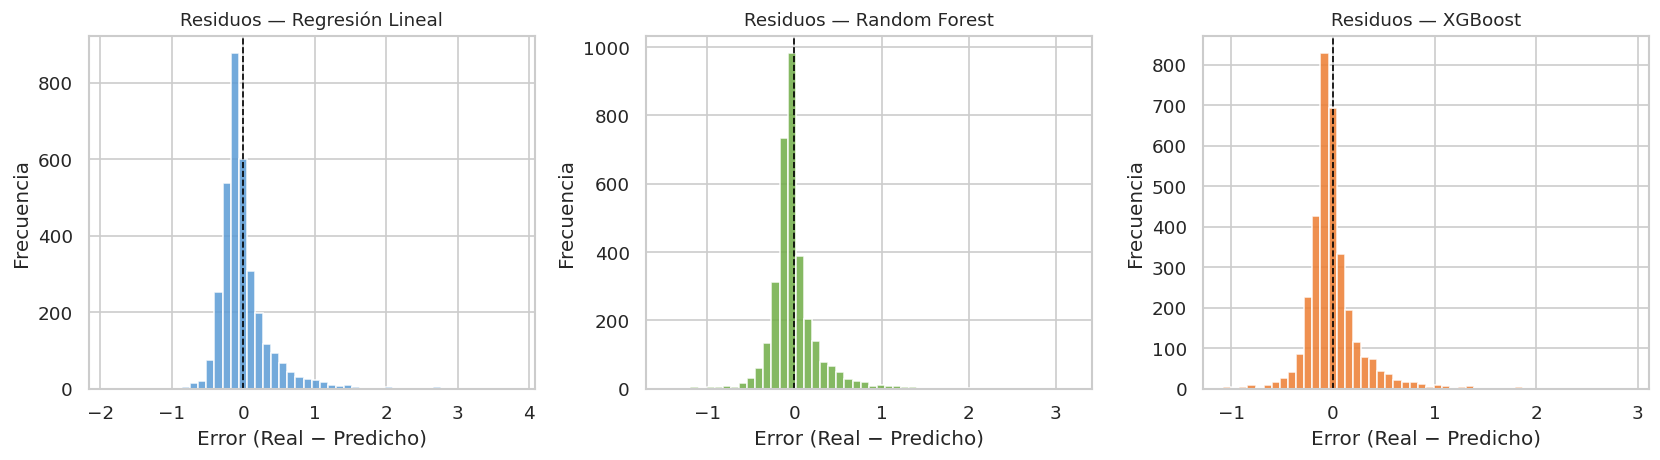

In [64]:
# Distribución de residuos
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (nombre, y_pred, color) in zip(axes, pares):
    residuos = y_test.values - y_pred
    ax.hist(residuos, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'Residuos — {nombre}', fontsize=11)
    ax.set_xlabel('Error (Real − Predicho)')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 8. Selección del modelo final y exportación

Se selecciona el modelo con mejor R² y menor RMSE en el conjunto de test.
El modelo ganador se exporta en formato `.pkl` para su uso en la aplicación Flask.

In [65]:
# Selección automática basada en R²
mejor_modelo_nombre = resultados['R2'].idxmax()
mejor_r2  = resultados.loc[mejor_modelo_nombre, 'R2']
mejor_rmse = resultados.loc[mejor_modelo_nombre, 'RMSE']

print(f'Modelo seleccionado : {mejor_modelo_nombre}')
print(f'R²  (test)          : {mejor_r2:.4f}')
print(f'RMSE (test)         : {mejor_rmse:.4f}')

modelos_dict = {
    'Regresión Lineal': lr,
    'Random Forest'   : rf,
    'XGBoost'         : xgb
}
modelo_final = modelos_dict[mejor_modelo_nombre]

Modelo seleccionado : XGBoost
R²  (test)          : 0.5250
RMSE (test)         : 0.2800


In [67]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/modelo_ventas.pkl", "wb") as f:
    pickle.dump(modelo_final, f)

print("Modelo guardado correctamente en models/modelo_ventas.pkl")

Modelo guardado correctamente en models/modelo_ventas.pkl


In [68]:
import os

ruta_modelo = "models/modelo_ventas.pkl"

if os.path.exists(ruta_modelo):
    print("Sí existe el archivo:", ruta_modelo)
    print("Tamaño en MB:", round(os.path.getsize(ruta_modelo) / (1024 * 1024), 2))
else:
    print("No existe el archivo")

Sí existe el archivo: models/modelo_ventas.pkl
Tamaño en MB: 1.18


In [69]:
from google.colab import files

files.download("models/modelo_ventas.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Conclusiones

| Modelo | RMSE | MAE | R² |
|---|---|---|---|
| Regresión Lineal | — | — | — |
| Random Forest | — | — | — |
| XGBoost | — | — | — |

*(Los valores se completan automáticamente al ejecutar el notebook.)*

**Justificación del modelo seleccionado:**

- La Regresión Lineal establece un baseline útil pero limitado: asume relaciones lineales que no capturan la complejidad del mercado de videojuegos (efectos de plataforma, género, editorial).
- Random Forest y XGBoost mejoran sustancialmente al modelar interacciones no lineales. Ambos manejan bien los outliers reales (blockbusters) al trabajar sobre `log_Global_Sales`.
- El modelo con mayor R² y menor RMSE en el conjunto de test es seleccionado como modelo final y exportado para su uso en la aplicación Flask.

In [66]:
import os
print(df.describe)

<bound method NDFrame.describe of                                 Name Platform  Year_of_Release         Genre  \
0                         Wii Sports      Wii             2006        Sports   
1                  Super Mario Bros.      NES             1985      Platform   
2                     Mario Kart Wii      Wii             2008        Racing   
3                  Wii Sports Resort      Wii             2009        Sports   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

     